# Notebook 02 — Data Curation Pipeline

**Project**: ML-Based QSAR Modeling for Anti-Leishmanial Sulfonamide Derivatives  
**Author**: [Your Name]  
**Date**: May 2026  
**Purpose**: Clean and standardize the raw ChEMBL dataset following  
Fourches et al. (2010, 2016) curation guidelines.

**Input**: `data/raw/chembl_all_targets_raw.csv`  
**Output**:
- `data/processed/curated_dataset.csv`
- `data/processed/sulfonamide_subset.csv`
- `data/processed/train_set.csv`
- `data/processed/test_set.csv`

### Curation Pipeline:
```
Raw Data → SMILES Standardization → Remove Invalid → Handle Duplicates
         → IC50 → pIC50 → Activity Classification → Drug-likeness Filter (Lipinski Ro5)
         → Train/Test Split → Curated Dataset
```

---

In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import sys
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import train_test_split

print(f"Project root: {PROJECT_ROOT}")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M')}")


Project root: E:\PhD_Projecttttttttttttt\PhD_QSAR_Leishmania
Timestamp: 2026-05-12 23:58


In [2]:
# ============================================================
# CELL 2: Load Raw Data
# ============================================================
raw_path = PROJECT_ROOT / 'data' / 'raw' / 'chembl_all_targets_raw.csv'
df = pd.read_csv(raw_path)
print(f"Loaded raw data: {len(df)} records, {df['molecule_chembl_id'].nunique()} unique compounds")
print(f"Targets: {df['target_name'].unique().tolist()}")
print(f"\nShape: {df.shape}")
df.head()


Loaded raw data: 25315 records, 13252 unique compounds
Targets: ['L_infantum', 'L_donovani', 'L_amazonensis', 'T_cruzi']

Shape: (25315, 19)


,assay_chembl_id,assay_description,assay_type,canonical_smiles,document_chembl_id,molecule_chembl_id,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,target_chembl_id,type,units,value,target_name,target_organism,data_source
0,CHEMBL703845,In vitro anti-leishmanial activity against pro...,F,C[N+](C)(C)CCOP(=O)([O-])OCCCCCCCCCCC=C1C2CC3C...,CHEMBL1146601,CHEMBL166092,5.17,=,=,IC50,nM,6750.0,CHEMBL612848,IC50,uM,6.75,L_infantum,Leishmania infantum,ChEMBL
1,CHEMBL703845,In vitro anti-leishmanial activity against pro...,F,CCCCCCCCCCCCCCC1CCC(OCCOP(=O)([O-])OCC[N+](C)(...,CHEMBL1146601,CHEMBL350978,4.63,=,=,IC50,nM,23300.0,CHEMBL612848,IC50,uM,23.30,L_infantum,Leishmania infantum,ChEMBL
2,CHEMBL703845,In vitro anti-leishmanial activity against pro...,F,CCCCCCCCCCCCCCCC=C1CCC(OCCOP(=O)([O-])OCC[N+]2...,CHEMBL1146601,CHEMBL166182,5.43,=,=,IC50,nM,3700.0,CHEMBL612848,IC50,uM,3.70,L_infantum,Leishmania infantum,ChEMBL
3,CHEMBL703845,In vitro anti-leishmanial activity against pro...,F,CCCCCCCCCCCCCCCC=C1CCC(OCCOP(=O)([O-])OCC[N+](...,CHEMBL1146601,CHEMBL165632,4.67,=,=,IC50,nM,21190.0,CHEMBL612848,IC50,uM,21.19,L_infantum,Leishmania infantum,ChEMBL
4,CHEMBL703845,In vitro anti-leishmanial activity against pro...,F,C[N+]1(CCOP(=O)([O-])OCCCCCCCCCCC=C2C3CC4CC(C3...,CHEMBL1146601,CHEMBL164620,4.65,=,=,IC50,nM,22580.0,CHEMBL612848,IC50,uM,22.58,L_infantum,Leishmania infantum,ChEMBL


## Step 1: SMILES Standardization\n\nFollowing Fourches et al. guidelines:\n- Remove salts and counterions (keep largest fragment)\n- Neutralize charges\n- Normalize tautomers\n- Canonicalize SMILES

In [3]:
# ============================================================
# CELL 3: SMILES Standardization
# ============================================================

def standardize_smiles(smiles):
    """Standardize SMILES: remove salts, neutralize, normalize, canonicalize."""
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return None
        remover = rdMolStandardize.LargestFragmentChooser()
        mol = remover.choose(mol)
        uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)
        normalizer = rdMolStandardize.Normalizer()
        mol = normalizer.normalize(mol)
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return None

print("Standardizing SMILES (this may take a few minutes)...")
df['std_smiles'] = df['canonical_smiles'].apply(standardize_smiles)

n_before = len(df)
df = df.dropna(subset=['std_smiles'])
print(f"  Valid after standardization: {len(df)}/{n_before} ({n_before - len(df)} removed)")


Standardizing SMILES (this may take a few minutes)...


[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer


[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running

[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running LargestFragmentChooser
[23:58:30] Running Uncharger
[23:58:30] Initializing Normalizer
[23:58:30] Running Normalizer
[23:58:30] Running

[23:58:31] Running LargestFragmentChooser
[23:58:31] Running Uncharger
[23:58:31] Initializing Normalizer
[23:58:31] Running Normalizer
[23:58:31] Running LargestFragmentChooser
[23:58:31] Running Uncharger
[23:58:31] Initializing Normalizer
[23:58:31] Running Normalizer
[23:58:31] Running LargestFragmentChooser
[23:58:31] Running Uncharger
[23:58:31] Initializing Normalizer
[23:58:31] Running Normalizer
[23:58:31] Running LargestFragmentChooser
[23:58:31] Running Uncharger
[23:58:31] Initializing Normalizer
[23:58:31] Running Normalizer
[23:58:31] Running LargestFragmentChooser
[23:58:31] Running Uncharger
[23:58:31] Initializing Normalizer
[23:58:31] Running Normalizer
[23:58:31] Running LargestFragmentChooser
[23:58:31] Running Uncharger
[23:58:31] Initializing Normalizer
[23:58:31] Running Normalizer
[23:58:31] Running LargestFragmentChooser
[23:58:31] Running Uncharger
[23:58:31] Initializing Normalizer
[23:58:31] Running Normalizer
[23:58:31] Running LargestFragmentChooser
[23:58

...

[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00

[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running

[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00

[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer
[00:00:20] Running LargestFragmentChooser
[00:00:20] Running Uncharger
[00:00:20] Initializing Normalizer
[00:00:20] Running Normalizer


  Valid after standardization: 25226/25315 (89 removed)


## Step 2: Remove Invalid Activity Entries

In [4]:
# ============================================================
# CELL 4: Remove Invalid Activities
# ============================================================
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
n_before = len(df)
df = df[df['standard_value'].notna()]
df = df[df['standard_value'] > 0]
print(f"After removing invalid activities: {len(df)}/{n_before}")


After removing invalid activities: 25222/25226

## Step 3: Handle Duplicates\n\n- **Concordant** (spread < 1 log unit): keep median\n- **Discordant** (spread ≥ 1 log unit): remove all

In [5]:
# ============================================================
# CELL 5: Handle Duplicates
# ============================================================

grouped = df.groupby(['std_smiles', 'target_name'])
clean_rows = []
removed_discordant = 0
merged_concordant = 0

for (smi, target), group in grouped:
    if len(group) == 1:
        clean_rows.append(group.iloc[0])
    else:
        log_values = np.log10(group['standard_value'].values.astype(float))
        spread = log_values.max() - log_values.min()
        if spread < 1.0:
            median_row = group.iloc[0].copy()
            median_row['standard_value'] = group['standard_value'].median()
            clean_rows.append(median_row)
            merged_concordant += len(group) - 1
        else:
            removed_discordant += len(group)

df = pd.DataFrame(clean_rows).reset_index(drop=True)
print(f"Merged {merged_concordant} concordant duplicates")
print(f"Removed {removed_discordant} discordant entries")
print(f"After deduplication: {len(df)} entries")


Merged 5463 concordant duplicates
Removed 3714 discordant entries
After deduplication: 16045 entries


## Step 4: Convert IC50 → pIC50

In [6]:
# ============================================================
# CELL 6: Activity Conversion and Classification
# ============================================================

# Convert IC50 (nM) to pIC50 = -log10(IC50 in M)
df['pIC50'] = -np.log10(df['standard_value'].astype(float) * 1e-9)
print(f"pIC50 range: {df['pIC50'].min():.2f} – {df['pIC50'].max():.2f}")
print(f"pIC50 median: {df['pIC50'].median():.2f}")

# Classify: Active (pIC50 >= 5, i.e., IC50 <= 10 μM) vs Inactive
THRESHOLD = 5.0
df['activity_class'] = df['pIC50'].apply(lambda x: 'Active' if x >= THRESHOLD else 'Inactive')

n_active = (df['activity_class'] == 'Active').sum()
print(f"\nActive: {n_active} ({n_active/len(df)*100:.1f}%)")
print(f"Inactive: {len(df) - n_active} ({(len(df)-n_active)/len(df)*100:.1f}%)")


pIC50 range: 1.30 – 10.77
pIC50 median: 5.11

Active: 8893 (55.4%)
Inactive: 7152 (44.6%)


## Step 5: Drug-likeness Filter (Lipinski's Rule of Five)

Lipinski's Rule of Five criteria:
- **MW** ≤ 500 Da
- **LogP** ≤ 5
- **HBD** (hydrogen bond donors) ≤ 5
- **HBA** (hydrogen bond acceptors) ≤ 10

Compounds with **≥ 2 violations** are removed as non-drug-like.  
Organometallic compounds (containing Fe, Cu, Zn, etc.) are also removed.

In [7]:
# ============================================================
# CELL 7: Drug-likeness Filter (Lipinski's Rule of Five)
# ============================================================

metals = {'Fe', 'Cu', 'Zn', 'Mn', 'Co', 'Ni', 'Pt', 'Pd', 'Ru',
          'Rh', 'Ir', 'Os', 'Au', 'Ag', 'Hg', 'Cd', 'Cr', 'Mo', 'W'}

keep_mask = []
lipinski_data = []
removed_metals = 0
removed_lipinski = 0

for _, row in df.iterrows():
    mol = Chem.MolFromSmiles(str(row['std_smiles']))
    if mol is None:
        keep_mask.append(False)
        lipinski_data.append({'MW': None, 'LogP': None, 'HBD': None, 'HBA': None, 'violations': None})
        continue

    # Check for metals (organometallics)
    atom_symbols = {atom.GetSymbol() for atom in mol.GetAtoms()}
    if atom_symbols & metals:
        keep_mask.append(False)
        removed_metals += 1
        lipinski_data.append({'MW': None, 'LogP': None, 'HBD': None, 'HBA': None, 'violations': None})
        continue

    # Lipinski's Rule of Five
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = Descriptors.NumHDonors(mol)
    hba  = Descriptors.NumHAcceptors(mol)
    violations = sum([mw > 500, logp > 5, hbd > 5, hba > 10])

    lipinski_data.append({'MW': mw, 'LogP': logp, 'HBD': hbd, 'HBA': hba, 'violations': violations})

    if violations >= 2:
        keep_mask.append(False)
        removed_lipinski += 1
    else:
        keep_mask.append(True)

n_before = len(df)
df = df[keep_mask].reset_index(drop=True)

print(f"Drug-likeness Filter (Lipinski's Rule of Five)")
print(f"  Before filter          : {n_before:,}")
print(f"  Removed (metals)       : {removed_metals}")
print(f"  Removed (Lipinski >=2) : {removed_lipinski:,}")
print(f"  After filter           : {len(df):,}")
print()

# Show Lipinski compliance summary
lip_df = pd.DataFrame(lipinski_data).dropna()
print("Lipinski Property Violations (before filtering):")
print(f"  MW  > 500:  {(lip_df['MW'] > 500).sum():,} ({(lip_df['MW'] > 500).mean()*100:.1f}%)")
print(f"  LogP > 5:   {(lip_df['LogP'] > 5).sum():,} ({(lip_df['LogP'] > 5).mean()*100:.1f}%)")
print(f"  HBD > 5:    {(lip_df['HBD'] > 5).sum():,} ({(lip_df['HBD'] > 5).mean()*100:.1f}%)")
print(f"  HBA > 10:   {(lip_df['HBA'] > 10).sum():,} ({(lip_df['HBA'] > 10).mean()*100:.1f}%)")


Drug-likeness Filter (Lipinski's Rule of Five)
  Before filter          : 16,045
  Removed (metals)       : 0
  Removed (Lipinski >=2) : 1,614
  After filter           : 14,431

Lipinski Property Violations (before filtering):
  MW  > 500:  2,006 (12.5%)
  LogP > 5:   3,839 (23.9%)
  HBD > 5:    250 (1.6%)
  HBA > 10:   329 (2.1%)


## Step 6: Add Scaffolds and Split Dataset

In [8]:
# ============================================================
# CELL 8: Murcko Scaffolds + Train/Test Split
# ============================================================

# Compute Murcko scaffolds
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return ''
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

print("Computing Murcko scaffolds...")
df['scaffold'] = df['std_smiles'].apply(get_scaffold)
print(f"Unique scaffolds: {df['scaffold'].nunique()}")

# Stratified random split (70/30)
train_df, test_df = train_test_split(
    df, test_size=0.30, random_state=42,
    stratify=df['activity_class']
)
print(f"\nTraining set: {len(train_df)} compounds")
print(f"Test set: {len(test_df)} compounds")
print(f"Train active ratio: {(train_df['activity_class'] == 'Active').mean():.1%}")
print(f"Test active ratio: {(test_df['activity_class'] == 'Active').mean():.1%}")


Computing Murcko scaffolds...


Unique scaffolds: 4750

Training set: 10101 compounds
Test set: 4330 compounds
Train active ratio: 54.1%
Test active ratio: 54.1%


In [9]:
# ============================================================
# CELL 9: Save Curated Datasets
# ============================================================
processed_dir = PROJECT_ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(processed_dir / 'curated_dataset.csv', index=False)
train_df.to_csv(processed_dir / 'train_set.csv', index=False)
test_df.to_csv(processed_dir / 'test_set.csv', index=False)

if 'is_sulfonamide' in df.columns:
    sulfo = df[df['is_sulfonamide']]
    sulfo.to_csv(processed_dir / 'sulfonamide_subset.csv', index=False)
    print(f"Sulfonamide subset: {len(sulfo)} compounds")

print("\nAll curated files saved:")
for f in sorted(processed_dir.glob('*.csv')):
    print(f"  ✓ {f.name}")



All curated files saved:
  ✓ curated_dataset.csv
  ✓ descriptor_names.csv
  ✓ selected_features.csv
  ✓ test_set.csv
  ✓ train_set.csv
  ✓ X_test.csv
  ✓ X_test_selected.csv
  ✓ X_train.csv
  ✓ X_train_selected.csv
  ✓ y_test.csv
  ✓ y_train.csv


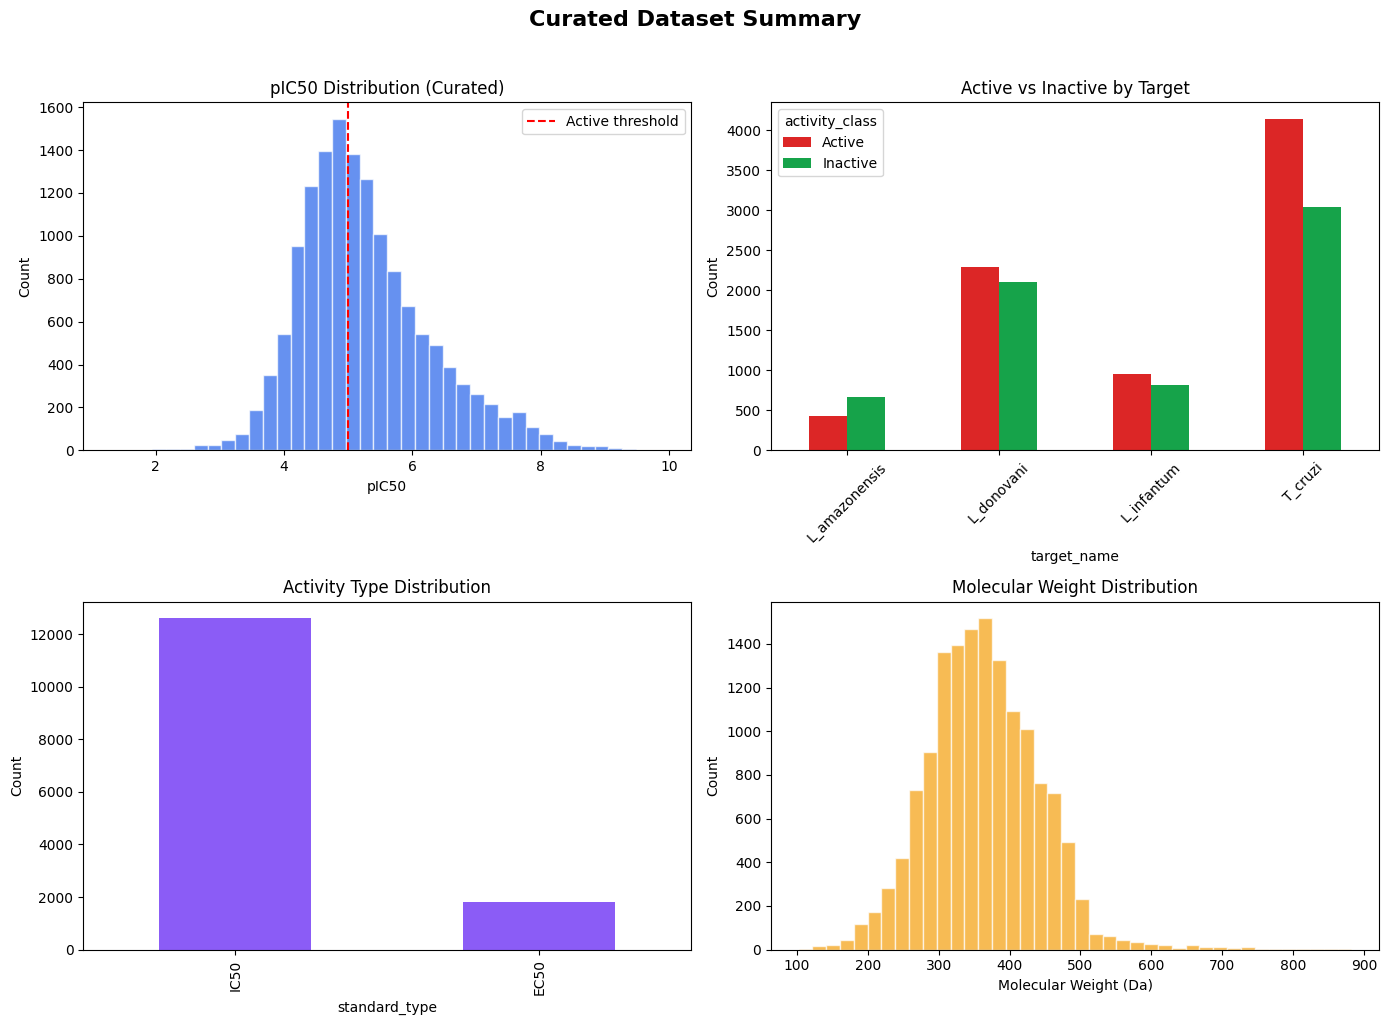


✓ Curation complete! Proceed to Notebook 03: Descriptor Calculation


In [10]:
# ============================================================
# CELL 10: Visualization — Curated Data Summary
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. pIC50 distribution
axes[0,0].hist(df['pIC50'], bins=40, color='#2563EB', alpha=0.7, edgecolor='white')
axes[0,0].axvline(x=5.0, color='red', linestyle='--', linewidth=1.5, label='Active threshold')
axes[0,0].set_xlabel('pIC50')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('pIC50 Distribution (Curated)')
axes[0,0].legend()

# 2. Class balance by target
class_counts = df.groupby(['target_name', 'activity_class']).size().unstack(fill_value=0)
class_counts.plot(kind='bar', ax=axes[0,1], color=['#DC2626', '#16A34A'])
axes[0,1].set_title('Active vs Inactive by Target')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Activity type distribution
df['standard_type'].value_counts().plot(kind='bar', ax=axes[1,0], color='#8B5CF6')
axes[1,0].set_title('Activity Type Distribution')
axes[1,0].set_ylabel('Count')

# 4. Molecular weight distribution
mw_values = []
for smi in df['std_smiles']:
    mol = Chem.MolFromSmiles(str(smi))
    if mol:
        mw_values.append(Descriptors.MolWt(mol))
axes[1,1].hist(mw_values, bins=40, color='#F59E0B', alpha=0.7, edgecolor='white')
axes[1,1].set_xlabel('Molecular Weight (Da)')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Molecular Weight Distribution')

plt.suptitle('Curated Dataset Summary', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'figures' / 'curated_data_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Curation complete! Proceed to Notebook 03: Descriptor Calculation")
